# Importar del notebook de parte 1

In [1]:
import os
print('Contenido de /kaggle/input:')
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print('  ', os.path.join(root, f))

Contenido de /kaggle/input:
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/preprocessing.py
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/graphs.py
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__results__.html
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/config.py
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__notebook__.ipynb
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/eda.py
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__output__.json
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/cleaning.py
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/custom.css
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__pycache__/graphs.cpython-312.pyc
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__pycache__/cleaning.cpython-312.pyc
   /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/__pycache__/preprocessing.cpython-312.pyc
   /kag

In [2]:
import glob, sys, os

hits = glob.glob('/kaggle/input/**/config.py', recursive=True)
if not hits:
    print('NO encontre config.py bajo /kaggle/input.')
    print('Esto adjuntado actualmente:')
    for root, _, files in os.walk('/kaggle/input'):
        for f in files:
            print('  ', os.path.join(root, f))
    raise SystemExit('Falta la salida de la Parte I. Re-guarda con "Save & Run All" '
                     'y re-adjunta su Output (ver pasos).')

src = os.path.dirname(hits[0])
sys.path.insert(0, src)
print('Modulos de la Parte I en:', src)

import config, preprocessing, cleaning, graphs
print('Artefactos Parquet en:', config.ARTIFACTS)

clean = cleaning.clean_subset()
G = graphs.build_graphs(clean)

Modulos de la Parte I en: /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1
Artefactos Parquet en: /kaggle/input/notebooks/mzuloetas/proyecto2-datamining-p1/artifacts
REPORTE DE LIMPIEZA -- Boise, ID

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 3
  - negocios sin atributos: 264
  - negocios sin price_range: 1,366
  - negocios sin horario: 412
  - outliers review_count (>p99=325), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 3,471
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 2,589
  - outliers review_count (>p99=486), marcados no eliminados: 439

[Check-ins]
  - total check-ins contados: 154,145

[Tips]
  - tips duplicados eliminados: 0

Filas tras limpieza:
  business : 2,941
  reviews  : 101,955
  users    : 43,934
  checkins : 2,474
  tips     : 11,436
GRAFOS

In [6]:
%%writefile ranking.py
import math
from collections import defaultdict
import pandas as pd


# ===================== PageRank (grafo de amistad) =====================
def pagerank(adj, nodes=None, d=0.85, max_iter=100, tol=1e-6):
    if nodes is None:
        nodes = list(adj)
    nodeset = set(nodes)
    N = len(nodes)
    nbrs = {u: [v for v in adj[u] if v in nodeset] for u in nodes}
    deg = {u: len(nbrs[u]) for u in nodes}
    pr = {u: 1.0 / N for u in nodes}
    base = (1 - d) / N
    for it in range(1, max_iter + 1):
        new = {u: base for u in nodes}
        dangling = 0.0
        for u in nodes:
            if deg[u] == 0:
                dangling += pr[u]
            else:
                share = d * pr[u] / deg[u]
                for v in nbrs[u]:
                    new[v] += share
        if dangling:
            add = d * dangling / N
            for u in new:
                new[u] += add
        diff = sum(abs(new[u] - pr[u]) for u in nodes)
        pr = new
        if diff < tol:
            break
    return pr, it


def top_pagerank(pr, users, k=15):
    s = pd.Series(pr, name='pagerank').sort_values(ascending=False).head(k)
    out = s.rename_axis('user_id').reset_index()
    cols = ['user_id', 'name', 'review_count', 'fans', 'n_friends_boise']
    info = users[[c for c in cols if c in users.columns]]
    return out.merge(info, on='user_id', how='left')


# ===================== HITS (bipartito usuario-negocio) =====================
def build_review_graph(reviews):
    user_to_biz = defaultdict(list)
    biz_to_users = defaultdict(list)
    for u, b in zip(reviews['user_id'], reviews['business_id']):
        user_to_biz[u].append(b)
        biz_to_users[b].append(u)
    return dict(user_to_biz), dict(biz_to_users)


def hits(user_to_biz, biz_to_users, max_iter=100, tol=1e-8):
    hub = {u: 1.0 for u in user_to_biz}
    auth = {b: 1.0 for b in biz_to_users}
    for it in range(1, max_iter + 1):
        new_auth = {b: sum(hub[u] for u in us) for b, us in biz_to_users.items()}
        na = math.sqrt(sum(v * v for v in new_auth.values())) or 1.0
        new_auth = {b: v / na for b, v in new_auth.items()}
        new_hub = {u: sum(new_auth[b] for b in bs) for u, bs in user_to_biz.items()}
        nh = math.sqrt(sum(v * v for v in new_hub.values())) or 1.0
        new_hub = {u: v / nh for u, v in new_hub.items()}
        diff = (sum(abs(new_auth[b] - auth[b]) for b in auth)
                + sum(abs(new_hub[u] - hub[u]) for u in hub))
        auth, hub = new_auth, new_hub
        if diff < tol:
            break
    return hub, auth, it


def top_authorities(auth, business, k=15):
    s = pd.Series(auth, name='authority').sort_values(ascending=False).head(k)
    out = s.rename_axis('business_id').reset_index()
    cols = ['business_id', 'name', 'stars', 'review_count', 'categories']
    info = business[[c for c in cols if c in business.columns]]
    return out.merge(info, on='business_id', how='left')


def top_hubs(hub, users, k=15):
    s = pd.Series(hub, name='hub').sort_values(ascending=False).head(k)
    out = s.rename_axis('user_id').reset_index()
    cols = ['user_id', 'name', 'review_count', 'fans', 'n_friends_boise']
    info = users[[c for c in cols if c in users.columns]]
    return out.merge(info, on='user_id', how='left')

Overwriting ranking.py


In [4]:
import importlib, ranking
importlib.reload(ranking)

pr, iters = ranking.pagerank(G['friend_adj'], nodes=G['lcc'])
print(f'PageRank convergio en {iters} iteraciones sobre el LCC ({len(G["lcc"]):,} usuarios)')

top = ranking.top_pagerank(pr, clean['users'], k=15)
top

PageRank convergio en 43 iteraciones sobre el LCC (11,233 usuarios)


,user_id,pagerank,name,review_count,fans,n_friends_boise
0,MN6vTCeRKWU44M7xwhQc7w,0.006709,Ophelia,966,857,553
1,kfAs5S1XGtZZyO0QCuXD_g,0.006127,Greg,477,231,515
2,G0Ex17NeMJUwqNIl8Z4ecw,0.005702,Michelle,211,147,463
3,Y-fPeP9dmciMYg83esNSWw,0.004968,Amie,339,164,473
4,q3y2k3IM8HaU5MkiD8DzXg,0.004099,StaciLei,122,59,322
5,yrBxqMkCx19SNdd71DpcRA,0.003631,Joseph,256,70,361
6,aDEQTk-GzjYug7xrwkollw,0.003145,Eric,54,33,318
7,3CwMwbY9UgP-qvTDxNs_0g,0.002893,Michele,1374,348,253
8,HXOfPXPMvdXNpQ_l0RRjKw,0.002867,Jeffrey,2453,739,217
9,8lEywHSvti2UjFP8ODbnHg,0.002845,Andrew,1392,346,234


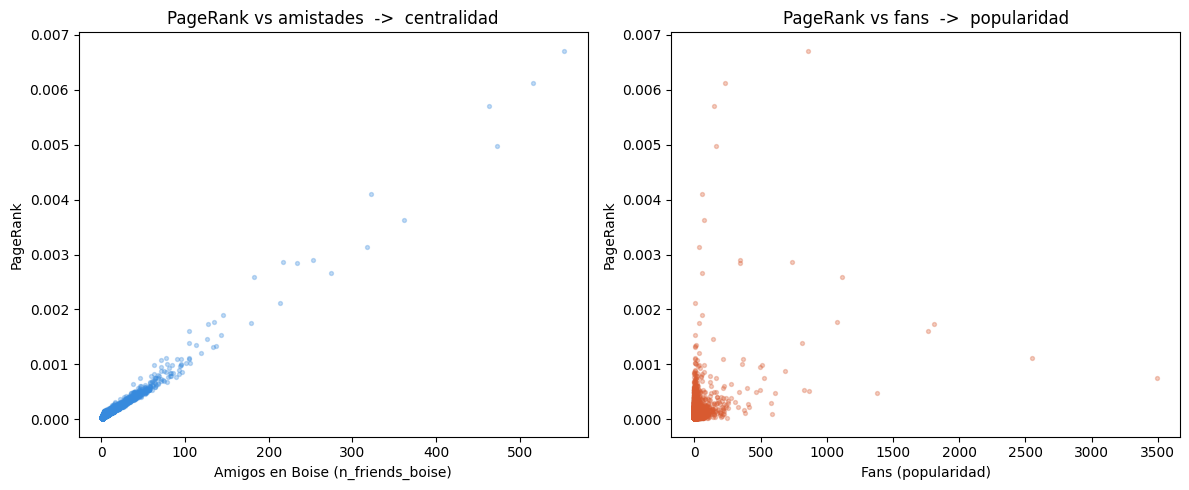

corr PageRank ~ n_friends_boise: 0.989
corr PageRank ~ fans:            0.332
corr PageRank ~ review_count:    0.171


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# PageRank + atributos para TODOS los usuarios del LCC
prdf = (pd.Series(pr, name='pagerank').rename_axis('user_id').reset_index()
        .merge(clean['users'][['user_id', 'name', 'fans', 'n_friends_boise', 'review_count']],
               on='user_id', how='left'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(prdf['n_friends_boise'], prdf['pagerank'], s=8, alpha=0.3, color='#378ADD')
axes[0].set_xlabel('Amigos en Boise (n_friends_boise)'); axes[0].set_ylabel('PageRank')
axes[0].set_title('PageRank vs amistades  ->  centralidad')

axes[1].scatter(prdf['fans'], prdf['pagerank'], s=8, alpha=0.3, color='#D85A30')
axes[1].set_xlabel('Fans (popularidad)'); axes[1].set_ylabel('PageRank')
axes[1].set_title('PageRank vs fans  ->  popularidad')
plt.tight_layout(); plt.show()

print('corr PageRank ~ n_friends_boise:', round(prdf['pagerank'].corr(prdf['n_friends_boise']), 3))
print('corr PageRank ~ fans:           ', round(prdf['pagerank'].corr(prdf['fans']), 3))
print('corr PageRank ~ review_count:   ', round(prdf['pagerank'].corr(prdf['review_count']), 3))

### HITS sobre el grafo bipartito

In [8]:
import importlib, ranking
importlib.reload(ranking)
import pandas as pd

u2b, b2u = ranking.build_review_graph(clean['reviews'])
hub, auth, it = ranking.hits(u2b, b2u)
print(f'HITS convergio en {it} iteraciones')
print(f'  {len(u2b):,} hubs (usuarios) | {len(b2u):,} authorities (negocios)\n')

print('TOP 15 AUTHORITIES (negocios mas importantes segun HITS):')
display(ranking.top_authorities(auth, clean['business'], k=15))

print('TOP 15 HUBS (resenadores mas importantes segun HITS):')
display(ranking.top_hubs(hub, clean['users'], k=15))

# authority vs simple popularidad
authdf = (pd.Series(auth, name='authority').rename_axis('business_id').reset_index()
          .merge(clean['business'][['business_id', 'review_count']], on='business_id'))
print('corr authority ~ review_count:', round(authdf['authority'].corr(authdf['review_count']), 3))

HITS convergio en 32 iteraciones
  43,934 hubs (usuarios) | 2,941 authorities (negocios)

TOP 15 AUTHORITIES (negocios mas importantes segun HITS):


,business_id,authority,name,stars,review_count,categories
0,jbJTF1zVmZsk4hea8hoeVA,0.535781,Fork,4.0,1810,"American (New), Burgers, Restaurants, Breakfas..."
1,3SM8CZuY5MiAruczCm556w,0.247835,Barbacoa Grill,4.0,1099,"Nightlife, Latin American, Steakhouses, Seafoo..."
2,w_4xUt-1AyY2ZwKtnjW0Xg,0.223897,Bittercreek Alehouse,4.5,998,"Bars, Gastropubs, Sandwiches, Nightlife, Resta..."
3,snTpO07JxjGhwJbE4RDFIA,0.217393,Goldy's Breakfast Bistro,4.5,949,"American (Traditional), Breakfast & Brunch, Re..."
4,sxx4KozLiedkxZ79U9W5qQ,0.149386,Big City Coffee,4.0,606,"Coffee & Tea, Breakfast & Brunch, Restaurants,..."
5,qmaI4o8RQC1SF9VsxY4VFw,0.143438,Boise Fry Company,4.0,704,"Restaurants, Food, American (New), Local Flavo..."
6,kK-pcrXr3CEnWP-ci7XXgw,0.134657,Luciano's,4.0,664,"Restaurants, Italian"
7,A_AEG20YPuVW7Ao7gkHicg,0.132153,Tin Roof Tacos,4.0,581,"Tex-Mex, Breakfast & Brunch, Mexican, American..."
8,6q_i-nV0R4r7bqjIHSKjFw,0.128802,10 Barrel Brewing - Boise,4.0,543,"Food, Breweries"
9,7GSOAWAlmIvKdbAVFBL_Cw,0.123537,Bardenay Restaurant & Distillery - Boise,4.0,553,"Pubs, Bars, Distilleries, Gluten-Free, America..."


TOP 15 HUBS (resenadores mas importantes segun HITS):


,user_id,hub,name,review_count,fans,n_friends_boise
0,MN6vTCeRKWU44M7xwhQc7w,0.134608,Ophelia,966,857,553
1,t2XuJjp_h9aRn-8ANoyc_Q,0.117753,Heather,477,55,275
2,Y-fPeP9dmciMYg83esNSWw,0.107061,Amie,339,164,473
3,E5Qm5W2BsMFCTirHq4DEIQ,0.102967,Laura,190,4,15
4,3CwMwbY9UgP-qvTDxNs_0g,0.091398,Michele,1374,348,253
5,xs3pZUUxRcblGuW7zzJ6iQ,0.088152,Justin,179,17,57
6,rI6Tqy2WR_ks5F47yYkZUw,0.088079,Amanda,206,17,42
7,jkBzSMPMVfzAgV4XqYzVMg,0.087277,Drew,262,21,59
8,M2NS_aQbMY2apoYjTlOCng,0.082001,John,590,50,80
9,TrFxVDCCwBXhn7hsdn_fQA,0.080235,Alison,268,31,57


corr authority ~ review_count: 0.954


### Louvain -> comunidades

In [12]:
%%writefile communities.py
"""
communities.py -- Parte II: deteccion de comunidades con Louvain.
Louvain a mano: movimiento local + agregacion por niveles. Sin librerias de grafos.
"""
from collections import defaultdict, Counter
import pandas as pd


def _build_weighted(adjacency):
    return {i: (dict(nbrs) if isinstance(nbrs, dict) else {j: 1.0 for j in nbrs})
            for i, nbrs in adjacency.items()}


def induced_subgraph(adj, nodes):
    s = set(nodes)
    return {u: {v for v in adj[u] if v in s} for u in nodes}


def _one_level(adj_w, m, resolution):
    nodes = list(adj_w)
    com = {i: i for i in nodes}
    k = {i: sum(adj_w[i].values()) for i in nodes}
    tot = dict(k)
    improved, any_imp = True, False
    while improved:
        improved = False
        for i in nodes:
            ci, ki = com[i], k[i]
            neigh = defaultdict(float)
            for j, w in adj_w[i].items():
                if j != i:
                    neigh[com[j]] += w
            tot[ci] -= ki
            best_c = ci
            best_gain = neigh.get(ci, 0.0) - resolution * tot[ci] * ki / (2 * m)
            for c, kin in neigh.items():
                gain = kin - resolution * tot[c] * ki / (2 * m)
                if gain > best_gain:
                    best_c, best_gain = c, gain
            tot[best_c] += ki
            com[i] = best_c
            if best_c != ci:
                improved = any_imp = True
    return com, any_imp


def louvain(adjacency, resolution=1.0, max_levels=50):
    adj_w = _build_weighted(adjacency)
    m = sum(sum(d.values()) for d in adj_w.values()) / 2.0
    if m == 0:
        return {i: 0 for i in adj_w}
    partition = {i: i for i in adj_w}
    cur = adj_w
    for _ in range(max_levels):
        com, improved = _one_level(cur, m, resolution)
        relab = {c: idx for idx, c in enumerate(sorted(set(com.values()), key=str))}
        com = {n: relab[c] for n, c in com.items()}
        partition = {orig: com[sup] for orig, sup in partition.items()}
        if not improved:
            break
        new = defaultdict(lambda: defaultdict(float))
        for i in cur:
            ci = com[i]
            for j, w in cur[i].items():
                new[ci][com[j]] += w
        cur = {c: dict(d) for c, d in new.items()}
    order = [c for c, _ in Counter(partition.values()).most_common()]
    remap = {c: idx for idx, c in enumerate(order)}
    return {n: remap[c] for n, c in partition.items()}


def modularity(adjacency, partition):
    adj_w = _build_weighted(adjacency)
    m = sum(sum(d.values()) for d in adj_w.values()) / 2.0
    if m == 0:
        return 0.0
    inc, tot = defaultdict(float), defaultdict(float)
    for i in adj_w:
        ci = partition[i]
        tot[ci] += sum(adj_w[i].values())
        for j, w in adj_w[i].items():
            if partition[j] == ci:
                inc[ci] += w
    return sum(inc[c] / (2 * m) - (tot[c] / (2 * m)) ** 2 for c in tot)


def community_summary(adj, partition, pr=None, users=None, top_k=5, n_key=5):
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    name_map = dict(zip(users['user_id'], users['name'])) if users is not None else {}
    rows = []
    for c, ms_list in sorted(members.items(), key=lambda kv: -len(kv[1]))[:top_k]:
        ms = set(ms_list)
        n = len(ms)
        ein = sum(1 for u in ms for v in adj[u] if v in ms) // 2
        eout = sum(1 for u in ms for v in adj[u] if v not in ms)
        density = 2 * ein / (n * (n - 1)) if n > 1 else 0
        if pr:
            key = sorted(ms, key=lambda x: pr.get(x, 0), reverse=True)[:n_key]
        else:
            key = sorted(ms, key=lambda x: len(adj[x]), reverse=True)[:n_key]
        rows.append({'comunidad': c, 'tamano': n, 'aristas_int': ein,
                     'densidad_int': round(density, 4), 'aristas_ext': eout,
                     'miembros_clave': [name_map.get(u, u) for u in key]})
    return pd.DataFrame(rows)

Overwriting communities.py


In [13]:
import importlib, communities
importlib.reload(communities)

lcc_adj = communities.induced_subgraph(G['friend_adj'], G['lcc'])
partition = communities.louvain(lcc_adj)
q = communities.modularity(lcc_adj, partition)
print(f'Louvain: {len(set(partition.values())):,} comunidades | modularidad Q = {q:.4f}')

summary = communities.community_summary(lcc_adj, partition, pr=pr, users=clean['users'], top_k=5)
summary

Louvain: 106 comunidades | modularidad Q = 0.5703


,comunidad,tamano,aristas_int,densidad_int,aristas_ext,miembros_clave
0,0,2342,6351,0.0023,2397,"[Greg, Michele, Jeffrey, Andrew, Katy]"
1,1,1707,5861,0.0040,4437,"[George, Christopher, Joe, Emmanuel, Joe]"
2,2,1519,4293,0.0037,3286,"[Andy, Marissa, Matt, Darby, Christopher]"
3,3,1485,4055,0.0037,3403,"[Ophelia, Michelle, Amie, StaciLei, Joseph]"
4,4,637,1013,0.0050,1409,"[Ryan, Minerva, Annelise, Jen, Terrence]"


In [14]:
import communities, importlib; importlib.reload(communities)
print([f for f in dir(communities) if not f.startswith('_')])

['Counter', 'community_summary', 'defaultdict', 'induced_subgraph', 'louvain', 'modularity', 'pd']


### Dibujando el grafo

In [15]:
%%writefile graphviz.py
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sample_subgraph(adj, partition, n_comms=6, per_comm=50, seed=0):
    rng = random.Random(seed)
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    top = sorted(members, key=lambda c: -len(members[c]))[:n_comms]
    sampled, node_comm = set(), {}
    for c in top:
        ms = members[c]
        pick = ms if len(ms) <= per_comm else rng.sample(ms, per_comm)
        for u in pick:
            sampled.add(u)
            node_comm[u] = c
    sub = {u: [v for v in adj[u] if v in sampled] for u in sampled}
    return sub, node_comm


def spring_layout(sub, iterations=100, seed=0):
    rng = random.Random(seed)
    nodes = list(sub)
    n = len(nodes)
    if n == 0:
        return {}
    pos = {u: [rng.uniform(0, 1), rng.uniform(0, 1)] for u in nodes}
    edges = set()
    for u in sub:
        for v in sub[u]:
            edges.add((u, v) if str(u) < str(v) else (v, u))
    k = math.sqrt(1.0 / n)
    t = 0.1
    dt = t / (iterations + 1)
    for _ in range(iterations):
        disp = {u: [0.0, 0.0] for u in nodes}
        for i in range(n):
            ui = nodes[i]; xi, yi = pos[ui]
            for j in range(i + 1, n):
                uj = nodes[j]
                dx = xi - pos[uj][0]; dy = yi - pos[uj][1]
                d = math.hypot(dx, dy) or 1e-6
                rep = k * k / d
                ux, uy = dx / d * rep, dy / d * rep
                disp[ui][0] += ux; disp[ui][1] += uy
                disp[uj][0] -= ux; disp[uj][1] -= uy
        for u, v in edges:
            dx = pos[u][0] - pos[v][0]; dy = pos[u][1] - pos[v][1]
            d = math.hypot(dx, dy) or 1e-6
            att = d * d / k
            ax_, ay_ = dx / d * att, dy / d * att
            disp[u][0] -= ax_; disp[u][1] -= ay_
            disp[v][0] += ax_; disp[v][1] += ay_
        for u in nodes:
            dx, dy = disp[u]
            d = math.hypot(dx, dy) or 1e-6
            lim = min(d, t)
            pos[u][0] += dx / d * lim
            pos[u][1] += dy / d * lim
        t -= dt
    return {u: tuple(p) for u, p in pos.items()}


def plot_communities(sub, node_comm, pos, pr=None, title=None):
    fig, ax = plt.subplots(figsize=(9, 9))
    for u in sub:
        for v in sub[u]:
            if str(u) < str(v):
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#cccccc', lw=0.3, alpha=0.5, zorder=1)
    comms = sorted(set(node_comm.values()))
    cmap = plt.cm.tab10
    color = {c: cmap(i % 10) for i, c in enumerate(comms)}
    nodes = list(sub)
    if pr:
        mx = max((pr.get(u, 0) for u in nodes), default=0) or 1.0
        sizes = [15 + 220 * (pr.get(u, 0) / mx) for u in nodes]
    else:
        sizes = [25] * len(nodes)
    ax.scatter([pos[u][0] for u in nodes], [pos[u][1] for u in nodes],
               c=[color[node_comm[u]] for u in nodes], s=sizes,
               edgecolors='white', linewidths=0.3, zorder=2)
    handles = [mpatches.Patch(color=color[c], label=f'Comunidad {c}') for c in comms]
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_title(title or 'Comunidades de amistad (muestra del LCC)')
    ax.axis('off')
    plt.tight_layout(); plt.show()

Writing graphviz.py


Muestra: 300 nodos de las 6 comunidades mas grandes


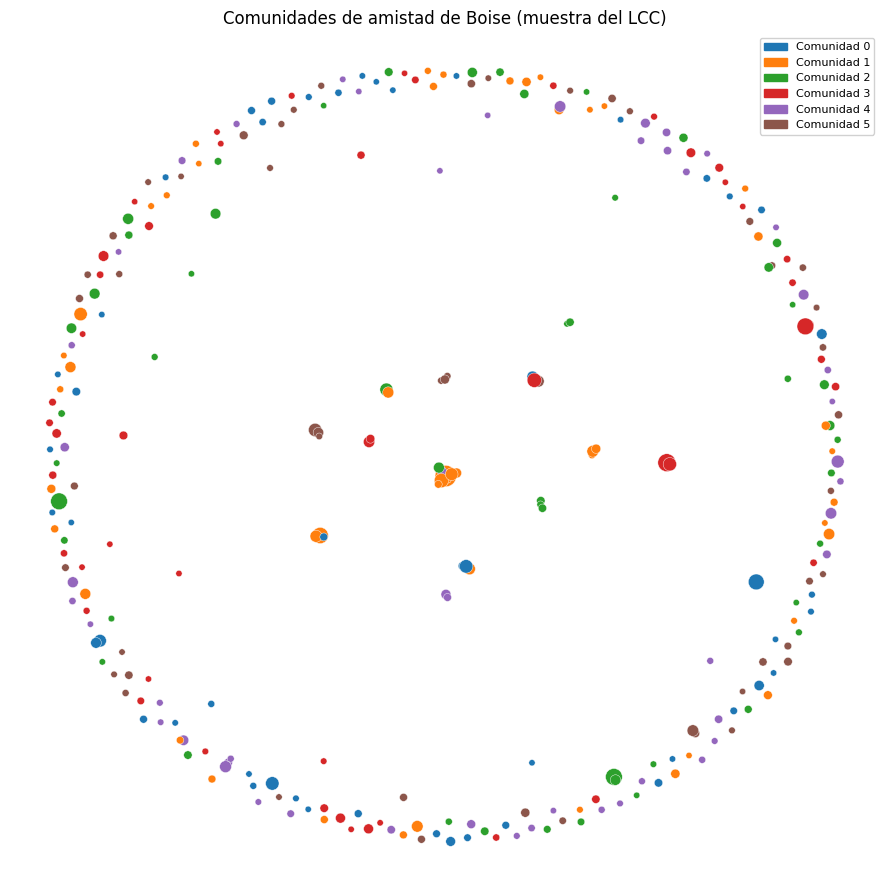

In [17]:
import importlib, graphviz
importlib.reload(graphviz)

sub, node_comm = graphviz.sample_subgraph(lcc_adj, partition, n_comms=6, per_comm=50)
print(f'Muestra: {len(sub):,} nodos de las 6 comunidades mas grandes')

pos = graphviz.spring_layout(sub, iterations=120)
graphviz.plot_communities(sub, node_comm, pos, pr=pr,
                          title='Comunidades de amistad de Boise (muestra del LCC)')

las comunidades son grandes (de 1500 a 2342 nodos) pero internamente dispersas (densidad aprox 0.003). 

Cuando muestreo 50 nodos al azar de aprox 2,000, la probabilidad de que dos de ellos estén conectados directamente es bajísima pq quedan aprox 3-4 aristas por comunidad. O sea, la mayoría de los 300 nodos muestreados quedan aislados (sin aristas entre sí). Y en un layout force-directed, los nodos sin aristas solo sienten repulsión osea se van todos al borde formando ese anillo. Los pocos cumulitos del centro son los que sí quedaron conectados.

### Version mejorada

In [18]:
%%writefile graphviz.py
import math
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sample_subgraph(adj, partition, pr=None, n_comms=6, per_comm=50, seed=0):
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    top = sorted(members, key=lambda c: -len(members[c]))[:n_comms]
    sampled, node_comm = set(), {}
    for c in top:
        ms = set(members[c])
        if pr:
            seed_node = max(ms, key=lambda x: pr.get(x, 0))
        else:
            seed_node = max(ms, key=lambda x: sum(1 for v in adj[x] if v in ms))
        seen, dq, order = {seed_node}, deque([seed_node]), []
        while dq and len(order) < per_comm:
            u = dq.popleft()
            order.append(u)
            for v in adj[u]:
                if v in ms and v not in seen:
                    seen.add(v)
                    dq.append(v)
        for u in order:
            sampled.add(u)
            node_comm[u] = c
    sub = {u: [v for v in adj[u] if v in sampled] for u in sampled}
    return sub, node_comm


def spring_layout(sub, iterations=100, seed=0):
    rng = random.Random(seed)
    nodes = list(sub)
    n = len(nodes)
    if n == 0:
        return {}
    pos = {u: [rng.uniform(0, 1), rng.uniform(0, 1)] for u in nodes}
    edges = set()
    for u in sub:
        for v in sub[u]:
            edges.add((u, v) if str(u) < str(v) else (v, u))
    k = math.sqrt(1.0 / n)
    t = 0.1
    dt = t / (iterations + 1)
    for _ in range(iterations):
        disp = {u: [0.0, 0.0] for u in nodes}
        for i in range(n):
            ui = nodes[i]; xi, yi = pos[ui]
            for j in range(i + 1, n):
                uj = nodes[j]
                dx = xi - pos[uj][0]; dy = yi - pos[uj][1]
                d = math.hypot(dx, dy) or 1e-6
                rep = k * k / d
                ux, uy = dx / d * rep, dy / d * rep
                disp[ui][0] += ux; disp[ui][1] += uy
                disp[uj][0] -= ux; disp[uj][1] -= uy
        for u, v in edges:
            dx = pos[u][0] - pos[v][0]; dy = pos[u][1] - pos[v][1]
            d = math.hypot(dx, dy) or 1e-6
            att = d * d / k
            ax_, ay_ = dx / d * att, dy / d * att
            disp[u][0] -= ax_; disp[u][1] -= ay_
            disp[v][0] += ax_; disp[v][1] += ay_
        for u in nodes:
            dx, dy = disp[u]
            d = math.hypot(dx, dy) or 1e-6
            lim = min(d, t)
            pos[u][0] += dx / d * lim
            pos[u][1] += dy / d * lim
        t -= dt
    return {u: tuple(p) for u, p in pos.items()}


def plot_communities(sub, node_comm, pos, pr=None, title=None):
    fig, ax = plt.subplots(figsize=(9, 9))
    for u in sub:
        for v in sub[u]:
            if str(u) < str(v):
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#cccccc', lw=0.3, alpha=0.5, zorder=1)
    comms = sorted(set(node_comm.values()))
    cmap = plt.cm.tab10
    color = {c: cmap(i % 10) for i, c in enumerate(comms)}
    nodes = list(sub)
    if pr:
        mx = max((pr.get(u, 0) for u in nodes), default=0) or 1.0
        sizes = [15 + 220 * (pr.get(u, 0) / mx) for u in nodes]
    else:
        sizes = [25] * len(nodes)
    ax.scatter([pos[u][0] for u in nodes], [pos[u][1] for u in nodes],
               c=[color[node_comm[u]] for u in nodes], s=sizes,
               edgecolors='white', linewidths=0.3, zorder=2)
    handles = [mpatches.Patch(color=color[c], label=f'Comunidad {c}') for c in comms]
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_title(title or 'Comunidades de amistad (muestra del LCC)')
    ax.axis('off')
    plt.tight_layout(); plt.show()

Overwriting graphviz.py


Muestra: 300 nodos | aristas: 692


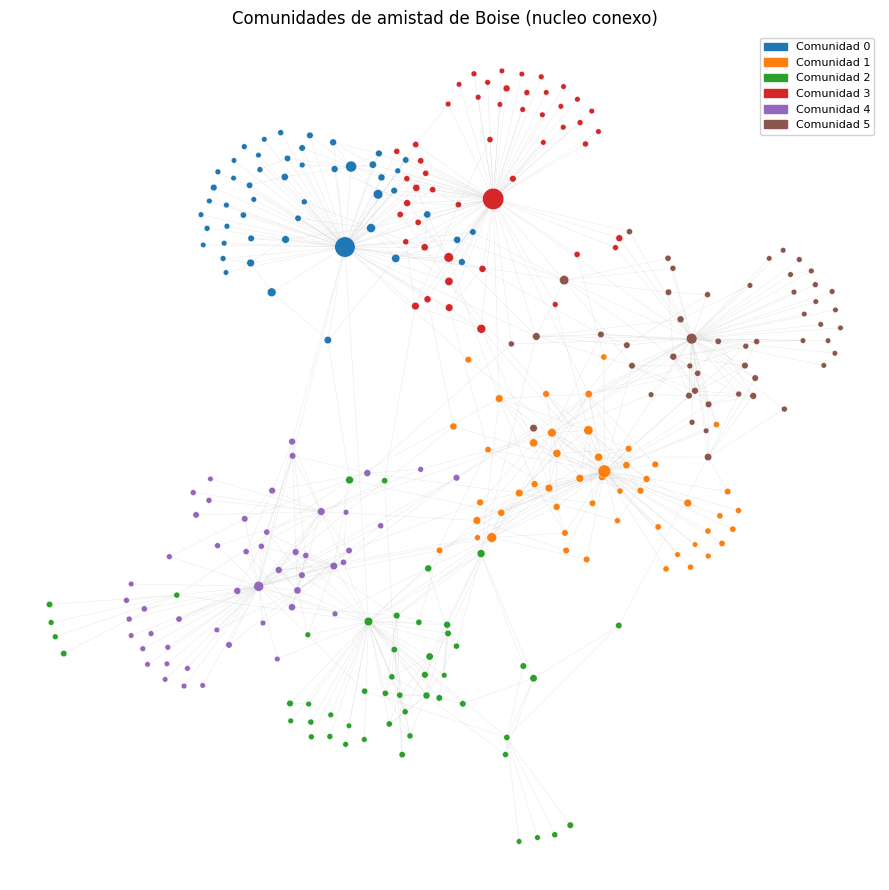

In [19]:
import importlib, graphviz
importlib.reload(graphviz)

sub, node_comm = graphviz.sample_subgraph(lcc_adj, partition, pr=pr, n_comms=6, per_comm=50)
print(f'Muestra: {len(sub):,} nodos | aristas: {sum(len(v) for v in sub.values())//2:,}')

pos = graphviz.spring_layout(sub, iterations=120)
graphviz.plot_communities(sub, node_comm, pos, pr=pr,
                          title='Comunidades de amistad de Boise (nucleo conexo)')

## Comparador Lentes de influencia

In [20]:
import pandas as pd

infl = (pd.concat([pd.Series(pr, name='pagerank'),
                   pd.Series(hub, name='hub')], axis=1, join='inner')
        .rename_axis('user_id').reset_index()
        .merge(clean['users'][['user_id', 'name', 'review_count', 'fans', 'n_friends_boise']],
               on='user_id', how='left'))
infl['pr_rank']  = infl['pagerank'].rank(ascending=False, method='min').astype(int)
infl['hub_rank'] = infl['hub'].rank(ascending=False, method='min').astype(int)

print('corr  PageRank ~ hub:', round(infl['pagerank'].corr(infl['hub']), 3))
top_pr  = set(infl.nsmallest(15, 'pr_rank')['user_id'])
top_hub = set(infl.nsmallest(15, 'hub_rank')['user_id'])
overlap = top_pr & top_hub
print(f'Solapamiento top-15 (influencia social vs reseñador): {len(overlap)}/15')

pilares = (infl[infl.user_id.isin(overlap)].sort_values('pagerank', ascending=False)
           [['name', 'pr_rank', 'hub_rank', 'review_count', 'fans', 'n_friends_boise']])
print('\nPilares de Boise (top en AMBOS lentes):')
display(pilares)

corr  PageRank ~ hub: 0.336
Solapamiento top-15 (influencia social vs reseñador): 4/15

Pilares de Boise (top en AMBOS lentes):


,name,pr_rank,hub_rank,review_count,fans,n_friends_boise
83,Ophelia,1,1,966,857,553
115,Amie,4,3,339,164,473
535,Michele,8,5,1374,348,253
375,Heather,11,2,477,55,275
